# One-Step LSTM Architecture Experiments

В этом ноутбуке сравниваются несколько архитектур one-step LSTM для HDFS anomaly detection. Все модели обучаются в одинаковом production-like сценарии: входом является скользящее окно `EventId`, модель предсказывает следующий `EventId`, а block-level anomaly score считается как доля top-k miss внутри `block_id`.

Для всех запусков используется early stopping: выбирается checkpoint с минимальным `val_loss`, затем на этом checkpoint считаются validation/test scores и подбирается threshold по максимуму F1 на validation.

## 1 Импорты и пути

In [1]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use('default')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for path in (current, *current.parents):
        if (path / 'configs').exists() and (path / 'src').exists():
            return path
    raise RuntimeError('Project root not found')


ROOT = find_project_root()
REPORT_ROOT = ROOT / 'reports' / 'lstm_one_step'
FIG_DIR = REPORT_ROOT / 'architecture_experiments' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('ROOT:', ROOT)
print('REPORT_ROOT:', REPORT_ROOT)

ROOT: /Users/andrew/PycharmProjects/hdfs-log-anomaly-detection
REPORT_ROOT: /Users/andrew/PycharmProjects/hdfs-log-anomaly-detection/reports/lstm_one_step


## 2 Загрузка результатов

In [2]:
def parse_run_name(run_name: str) -> dict:
    pattern = r'token_e(?P<embedding_dim>\d+)_h(?P<hidden_size>\d+)_l(?P<num_layers>\d+)_d(?P<dropout>\d+)'
    match = re.fullmatch(pattern, run_name)
    if match is None:
        return {
            'embedding_dim': np.nan,
            'hidden_size': np.nan,
            'num_layers': np.nan,
            'dropout': np.nan,
        }
    values = match.groupdict()
    return {
        'embedding_dim': int(values['embedding_dim']),
        'hidden_size': int(values['hidden_size']),
        'num_layers': int(values['num_layers']),
        'dropout': int(values['dropout']) / 10,
    }


def load_history(run_dir: Path) -> dict:
    path = run_dir / 'tables' / 'lstm_one_step_history.json'
    with path.open('r', encoding='utf-8') as file:
        return json.load(file)


def load_run_metrics(run_dir: Path) -> list[dict]:
    tables_dir = run_dir / 'tables'
    history = load_history(run_dir)
    rows = []
    for split, filename in [
        ('validation', 'lstm_one_step_validation_metrics.csv'),
        ('test', 'lstm_one_step_test_metrics.csv'),
    ]:
        path = tables_dir / filename
        if not path.exists():
            continue
        row = pd.read_csv(path).iloc[0].to_dict()
        row['split'] = split
        row['run_name'] = run_dir.name
        row['best_epoch'] = history.get('best_epoch')
        row['best_val_loss'] = history.get('best_val_loss')
        row['epochs_ran'] = len(history.get('epoch', []))
        row.update(parse_run_name(run_dir.name))
        rows.append(row)
    return rows


run_dirs = sorted(
    run_dir for run_dir in REPORT_ROOT.iterdir()
    if run_dir.is_dir() and (run_dir / 'tables' / 'lstm_one_step_test_metrics.csv').exists()
)
metrics = pd.DataFrame([row for run_dir in run_dirs for row in load_run_metrics(run_dir)])
history = pd.concat(
    [pd.DataFrame(load_history(run_dir)).assign(run_name=run_dir.name) for run_dir in run_dirs],
    ignore_index=True,
)

ordered_runs = (
    metrics[metrics['split'] == 'test']
    .sort_values('f1', ascending=False)['run_name']
    .tolist()
)

metric_columns = [
    'run_name', 'split', 'embedding_dim', 'hidden_size', 'num_layers', 'dropout',
    'epochs_ran', 'best_epoch', 'best_val_loss', 'threshold',
    'f1', 'precision', 'recall', 'fpr', 'average_precision', 'tn', 'fp', 'fn', 'tp',
]
display(metrics[metric_columns].sort_values(['split', 'f1'], ascending=[True, False]).round(4))

,run_name,split,embedding_dim,hidden_size,num_layers,dropout,epochs_ran,best_epoch,best_val_loss,threshold,f1,precision,recall,fpr,average_precision,tn,fp,fn,tp
1,token_e32_h64_l1_d00,test,32,64,1,0.0,3,2,0.2893,0.0870,0.7061,0.7465,0.6699,0.0305,0.6714,54121,1702,2469,5011
5,token_e64_h256_l1_d00,test,64,256,1,0.0,2,1,0.2790,0.0938,0.6728,0.7727,0.5957,0.0235,0.6531,54512,1311,3024,4456
3,token_e64_h128_l1_d00,test,64,128,1,0.0,3,2,0.2870,0.0938,0.6666,0.6810,0.6528,0.0410,0.6426,53536,2287,2597,4883
0,token_e32_h64_l1_d00,validation,32,64,1,0.0,3,2,0.2893,0.0870,0.6070,0.5511,0.6754,0.0312,0.5332,54080,1742,1028,2139
4,token_e64_h256_l1_d00,validation,64,256,1,0.0,2,1,0.2790,0.0938,0.5936,0.5755,0.6129,0.0257,0.5275,54390,1432,1226,1941
2,token_e64_h128_l1_d00,validation,64,128,1,0.0,3,2,0.2870,0.0938,0.5471,0.4637,0.6672,0.0438,0.4483,53378,2444,1054,2113


**Промежуточный вывод.** Все три эксперимента используют одинаковый pipeline: train на окнах, early stopping по `val_loss`, threshold selection по validation F1 и финальная оценка на test. Поэтому различия в метриках можно интерпретировать как влияние размера embedding/hidden state при фиксированной one-step постановке.

## 3 Сравнение test metrics

,run_name,embedding_dim,hidden_size,best_epoch,threshold,f1,precision,recall,fpr,average_precision,fp,fn
1,token_e32_h64_l1_d00,32,64,2,0.0870,0.7061,0.7465,0.6699,0.0305,0.6714,1702,2469
5,token_e64_h256_l1_d00,64,256,1,0.0938,0.6728,0.7727,0.5957,0.0235,0.6531,1311,3024
3,token_e64_h128_l1_d00,64,128,2,0.0938,0.6666,0.6810,0.6528,0.0410,0.6426,2287,2597


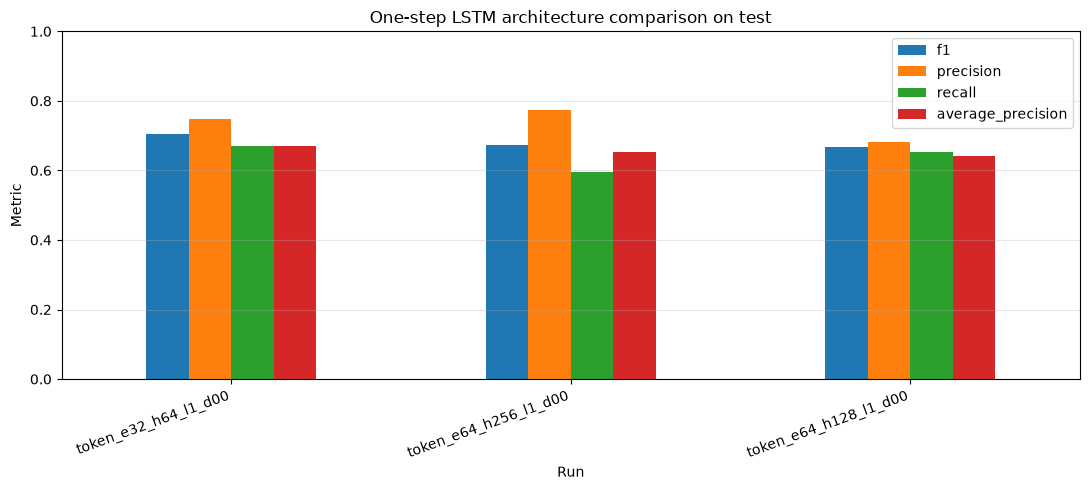

In [3]:
test_metrics = metrics[metrics['split'] == 'test'].copy()
test_metrics['run_name'] = pd.Categorical(test_metrics['run_name'], categories=ordered_runs, ordered=True)
test_metrics = test_metrics.sort_values('run_name')

display(
    test_metrics[
        ['run_name', 'embedding_dim', 'hidden_size', 'best_epoch', 'threshold',
         'f1', 'precision', 'recall', 'fpr', 'average_precision', 'fp', 'fn']
    ].round(4)
)

plot_columns = ['f1', 'precision', 'recall', 'average_precision']
ax = test_metrics.set_index('run_name')[plot_columns].plot(kind='bar', figsize=(11, 5))
ax.set_title('One-step LSTM architecture comparison on test')
ax.set_xlabel('Run')
ax.set_ylabel('Metric')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'one_step_architecture_test_metrics.png', dpi=150)
plt.show()

**Промежуточный вывод.** Лучший test F1 среди проверенных архитектур показывает самая простая модель `token_e32_h64_l1_d00`. Более крупные модели не улучшают итоговый F1: `h256` даёт более высокий precision и ниже FPR, но теряет recall; `h128` уступает базовой модели почти по всем основным test-метрикам.

## 4 Precision/recall/FPR trade-off

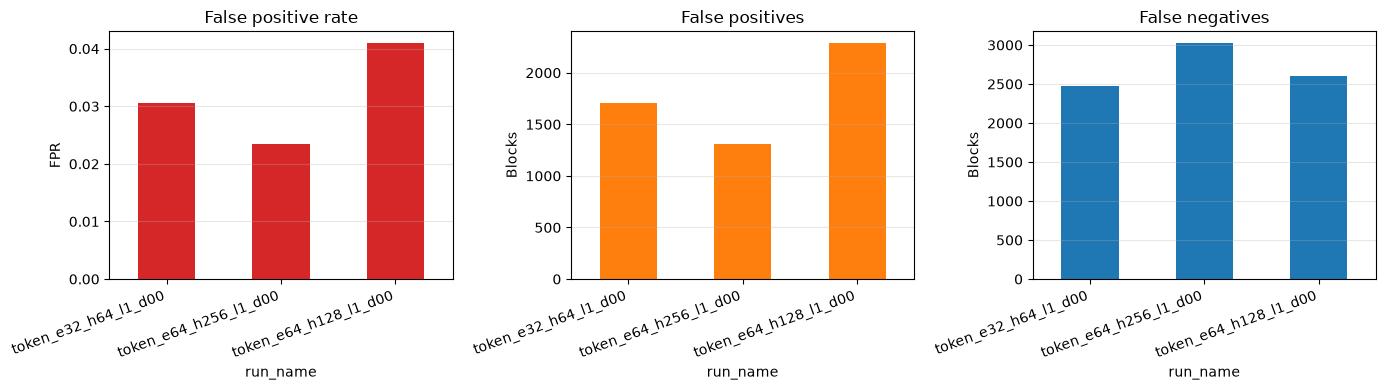

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

test_metrics.set_index('run_name')['fpr'].plot(kind='bar', ax=axes[0], color='tab:red')
axes[0].set_title('False positive rate')
axes[0].set_ylabel('FPR')
axes[0].grid(axis='y', alpha=0.3)

test_metrics.set_index('run_name')['fp'].plot(kind='bar', ax=axes[1], color='tab:orange')
axes[1].set_title('False positives')
axes[1].set_ylabel('Blocks')
axes[1].grid(axis='y', alpha=0.3)

test_metrics.set_index('run_name')['fn'].plot(kind='bar', ax=axes[2], color='tab:blue')
axes[2].set_title('False negatives')
axes[2].set_ylabel('Blocks')
axes[2].grid(axis='y', alpha=0.3)

for ax in axes:
    ax.tick_params(axis='x', rotation=20)
    for label in ax.get_xticklabels():
        label.set_ha('right')

plt.tight_layout()
plt.savefig(FIG_DIR / 'one_step_architecture_errors.png', dpi=150)
plt.show()

**Промежуточный вывод.** Увеличение hidden size до 256 делает модель более консервативной: она реже ошибочно помечает нормальные блоки как аномальные (`FPR ≈ 0.024`), но чаще пропускает реальные аномалии. Базовая модель лучше балансирует precision и recall, поэтому получает максимальный F1.

## 5 Validation vs test

,run_name,average_precision_test,average_precision_validation,f1_test,f1_validation,fpr_test,fpr_validation,precision_test,precision_validation,recall_test,recall_validation,f1_gap_test_minus_validation
0,token_e32_h64_l1_d00,0.6714,0.5332,0.7061,0.6070,0.0305,0.0312,0.7465,0.5511,0.6699,0.6754,0.0991
2,token_e64_h256_l1_d00,0.6531,0.5275,0.6728,0.5936,0.0235,0.0257,0.7727,0.5755,0.5957,0.6129,0.0792
1,token_e64_h128_l1_d00,0.6426,0.4483,0.6666,0.5471,0.0410,0.0438,0.6810,0.4637,0.6528,0.6672,0.1195


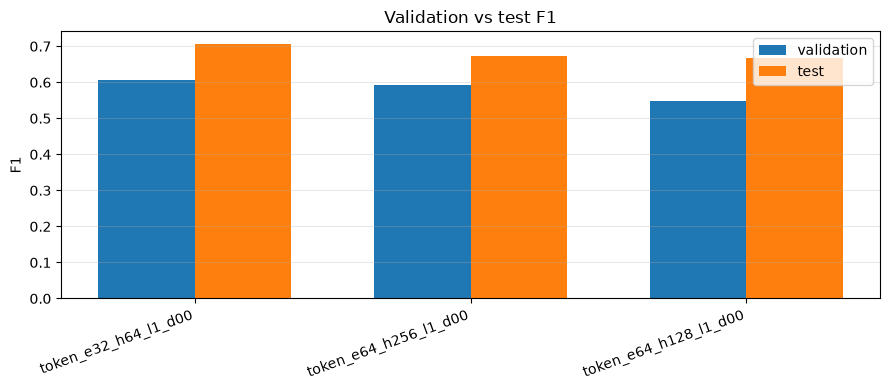

In [5]:
comparison = (
    metrics.pivot_table(
        index='run_name',
        columns='split',
        values=['f1', 'precision', 'recall', 'fpr', 'average_precision'],
        aggfunc='first',
    )
)
comparison.columns = [f'{metric}_{split}' for metric, split in comparison.columns]
comparison = comparison.reset_index()
comparison['run_name'] = pd.Categorical(comparison['run_name'], categories=ordered_runs, ordered=True)
comparison = comparison.sort_values('run_name')
comparison['f1_gap_test_minus_validation'] = comparison['f1_test'] - comparison['f1_validation']

display(comparison.round(4))

fig, ax = plt.subplots(figsize=(9, 4))
width = 0.35
x = np.arange(len(comparison))
ax.bar(x - width / 2, comparison['f1_validation'], width, label='validation')
ax.bar(x + width / 2, comparison['f1_test'], width, label='test')
ax.set_xticks(x, comparison['run_name'], rotation=20, ha='right')
ax.set_ylabel('F1')
ax.set_title('Validation vs test F1')
ax.grid(axis='y', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'one_step_architecture_validation_vs_test.png', dpi=150)
plt.show()

**Промежуточный вывод.** На всех архитектурах test F1 выше validation F1. Это говорит о том, что validation split оказался сложнее или отличается по распределению. Тем не менее validation используется только для выбора checkpoint и threshold, а окончательное сравнение моделей проводится по test split.

## 6 Training curves и выбранные checkpoints

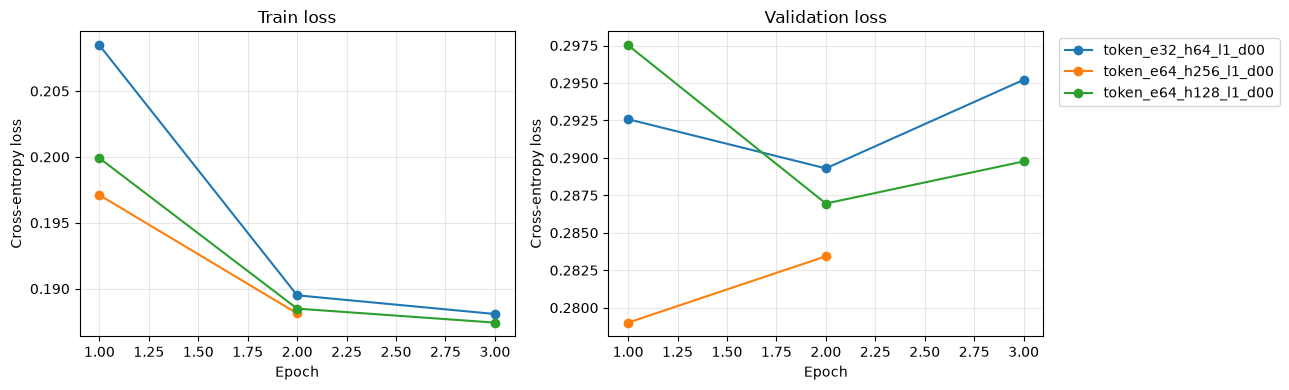

,run_name,embedding_dim,hidden_size,epochs_ran,best_epoch,best_val_loss
1,token_e32_h64_l1_d00,32,64,3,2,0.2893
3,token_e64_h128_l1_d00,64,128,3,2,0.2870
5,token_e64_h256_l1_d00,64,256,2,1,0.2790


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=False)

for run_name in ordered_runs:
    run_history = history[history['run_name'] == run_name]
    axes[0].plot(run_history['epoch'], run_history['train_loss'], marker='o', label=run_name)
    axes[1].plot(run_history['epoch'], run_history['val_loss'], marker='o', label=run_name)

axes[0].set_title('Train loss')
axes[1].set_title('Validation loss')
for ax in axes:
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Cross-entropy loss')
    ax.grid(alpha=0.3)
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(FIG_DIR / 'one_step_architecture_training_curves.png', dpi=150)
plt.show()

best_checkpoints = (
    metrics[metrics['split'] == 'test'][
        ['run_name', 'embedding_dim', 'hidden_size', 'epochs_ran', 'best_epoch', 'best_val_loss']
    ]
    .sort_values('run_name')
)
display(best_checkpoints.round(4))

**Промежуточный вывод.** Early stopping выбирает разные checkpoints для разных архитектур. У `h256` лучший `val_loss` достигается уже на 1-й эпохе, что указывает на быстрое переобучение более ёмкой модели. Базовая и `h128` модели выбирают 2-ю эпоху.

## 7 Итоговое ранжирование

In [7]:
ranking = test_metrics[
    ['run_name', 'embedding_dim', 'hidden_size', 'best_epoch', 'threshold',
     'f1', 'precision', 'recall', 'fpr', 'average_precision', 'fp', 'fn']
].copy()
ranking['rank_by_f1'] = ranking['f1'].rank(ascending=False, method='min').astype(int)
ranking['rank_by_ap'] = ranking['average_precision'].rank(ascending=False, method='min').astype(int)
ranking['rank_by_fpr'] = ranking['fpr'].rank(ascending=True, method='min').astype(int)
ranking = ranking.sort_values(['rank_by_f1', 'rank_by_ap'])
display(ranking.round(4))

,run_name,embedding_dim,hidden_size,best_epoch,threshold,f1,precision,recall,fpr,average_precision,fp,fn,rank_by_f1,rank_by_ap,rank_by_fpr
1,token_e32_h64_l1_d00,32,64,2,0.0870,0.7061,0.7465,0.6699,0.0305,0.6714,1702,2469,1,1,2
5,token_e64_h256_l1_d00,64,256,1,0.0938,0.6728,0.7727,0.5957,0.0235,0.6531,1311,3024,2,2,1
3,token_e64_h128_l1_d00,64,128,2,0.0938,0.6666,0.6810,0.6528,0.0410,0.6426,2287,2597,3,3,3


## Итоговый вывод

Сравнение архитектур показывает, что для one-step LSTM увеличение размера модели не даёт устойчивого улучшения итогового качества. Лучшая по test F1 конфигурация - базовая `token_e32_h64_l1_d00`: `F1 ≈ 0.706`, `precision ≈ 0.747`, `recall ≈ 0.670`, `FPR ≈ 0.031`, `average precision ≈ 0.671`.

Более крупная модель `token_e64_h256_l1_d00` снижает FPR и повышает precision, но делает это ценой заметного падения recall. Это означает, что она становится более консервативной: реже поднимает ложную тревогу, но чаще пропускает аномальные блоки. Конфигурация `token_e64_h128_l1_d00` не улучшает baseline ни по F1, ни по average precision.

Вывод: one-step LSTM полезна как последовательный baseline, но дальнейшее увеличение архитектуры не выглядит главным источником качества. Ограничение скорее находится в самой one-step постановке и top-k miss aggregation. Поэтому после фиксации базовой one-step модели логично переходить к many-to-many LSTM и сравнению более выразительных scoring strategies (`nll_mean`, `nll_p95`, `nll_max`).